In [1]:
import pandas as pd 

train = pd.read_csv('ship/train.csv')

Vẽ đồ thị để so sánh tương quan giữa 2 labels của target, nếu có sự chênh lệch lớn, ta sẽ dùng thêm giá trị riêng để đánh giá độ chính xác của model. 

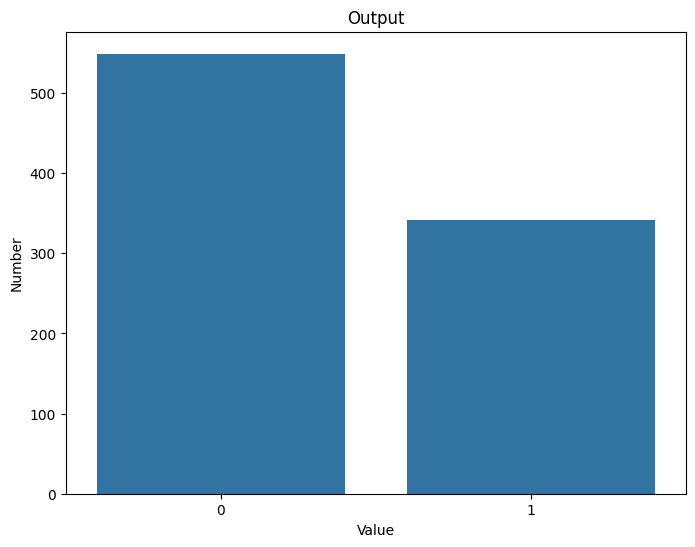

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns 

plt.figure(figsize=(8,6))
sns.countplot(x='Survived', data=train)
plt.title('Output')
plt.xlabel('Value')
plt.ylabel('Number')
plt.show()

sự chênh lệch giữa 2 nhóm không nhiều, ta có thể đi qua bước tiếp theo, xử lý các giá trị missing. 

In [3]:
numerical = train.select_dtypes(include=['int64', 'float64']).columns
categorical = train.select_dtypes(include='object').columns 

def missing(df, feature):
    total = df[feature].isnull().sum()
    percentage = (total / len(df)) * 100
    stats = pd.DataFrame({'missing': total, 'Percent': percentage})
    stats = stats[stats['missing'] > 0]
    return stats 

num = missing(train, numerical)
print('for numerical: ')
print(num)

cat = missing(train, categorical)
print(' \n for categorical: ')
print(cat)

print(len(numerical))
print(len(categorical))

print(numerical.tolist())
print(categorical.tolist())

for numerical: 
     missing   Percent
Age      177  19.86532
 
 for categorical: 
          missing    Percent
Cabin         687  77.104377
Embarked        2   0.224467
7
5
['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


'PassengerId'   - bỏ 
'Ticket' - ở mức cơ bản, ta tạm thời bỏ qua feature này 
'Name'  - ở mức cơ bản, ta tạm thời bỏ qua feature này
'Cabin'  - thiếu nhiều, bỏ feature này 


'Survived'   - target, nhớ encode 


'Sex'  - giữ
'Pclass'   - giữ 


'Age'  - điền mising bằng median 
'Embarked'  - điền bằng giá trị xuất hiện nhiều nhất 


'Fare'  - kiểm tra độ outlier và transform nếu cần


'SibSp'  - 
'Parch'  - 

In [4]:
train['Age'] = train['Age'].fillna(train['Age'].median())
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])

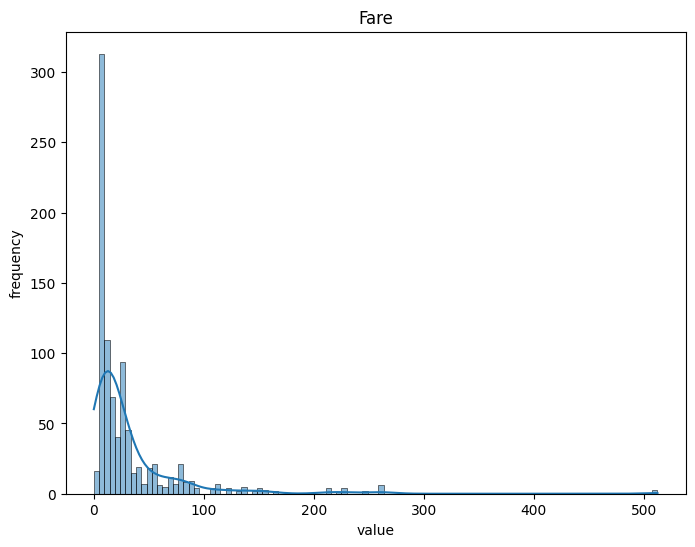

4.787316519674893
Fare per Person Q1: 7.9104
Fare per Person Median (Q2): 14.4542
Fare per Person Q3: 31.0


In [5]:
plt.figure(figsize=(8,6))
sns.histplot(train['Fare'], kde = True)
plt.title('Fare')
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

skew = train['Fare'].skew()
print(skew)

fare_q1 = train['Fare'].quantile(0.25)
fare_q2 = train['Fare'].quantile(0.50)
fare_q3 = train['Fare'].quantile(0.75)

print("Fare per Person Q1:", fare_q1)
print("Fare per Person Median (Q2):", fare_q2)
print("Fare per Person Q3:", fare_q3)

Oulier cao, nhiều. Thông thường ta sẽ transform lập tức để không xảy ra tình trạng này, nhưng trước đó, mình có thể thử một logic như sau: 

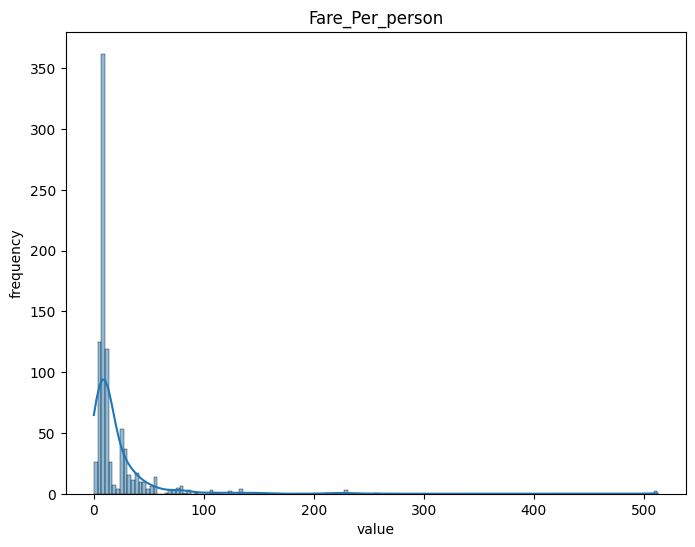

7.765594881854595
Fare per Person Q1: 7.25
Fare per Person Median (Q2): 8.3
Fare per Person Q3: 23.666666666666668


In [6]:
train['Family'] = train['SibSp'] + train['Parch'] + 1
train['Fare_per_person'] = train['Fare'] / train['Family']

plt.figure(figsize=(8,6))
sns.histplot(train['Fare_per_person'], kde= True)
plt.title('Fare_Per_person')
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

skew = train['Fare_per_person'].skew()
print(skew)

fare_q1 = train['Fare_per_person'].quantile(0.25)
fare_q2 = train['Fare_per_person'].quantile(0.50)
fare_q3 = train['Fare_per_person'].quantile(0.75)

print("Fare per Person Q1:", fare_q1)
print("Fare per Person Median (Q2):", fare_q2)
print("Fare per Person Q3:", fare_q3)

Nhờ vào việc tính Fare_per_person nên số lượng outlier giảm và được đưa vào vị trí ổn định. Nhưng độ skewness tăng mạnh, điều này suy ra, có hành khách đi 1 mình nhưng giá vé VIP trả ra rất cao so với mặt bằng chung, suy ra đến bước này ta sẽ dùng đến log transform. 

Note: khi dùng log_transform để dự đoán thì nhớ kết quả phải đi qua giai đoạn ngược lại log để lấy giá trị đúng. 
Các features còn lại của ta sẽ là 

'Survived'   - target, không cần encode


'Sex'  - giữ - LabelEncoder 
'Pclass'   - giữ - OHE 

'Age'  - đã điền mising bằng median 
'Embarked'  - đã điền bằng giá trị xuất hiện nhiều nhất - OHE 
'Fare_per_person'  - transform bằng log
'Family'  - encode là đi một mình hay không - LabelEncoder 

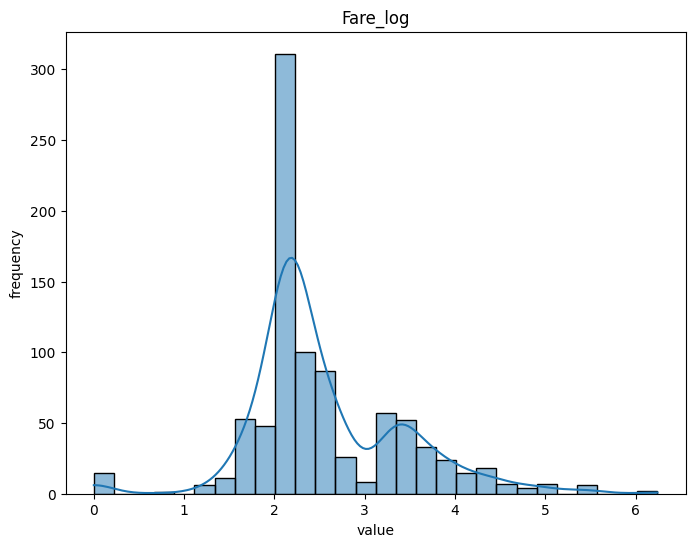

0.690259515942463


In [7]:
import numpy as np 
train['Fare_log'] = np.log1p(train['Fare_per_person'])

plt.figure(figsize=(8,6))
sns.histplot(train['Fare_log'], kde= True)
plt.title('Fare_log')
plt.xlabel('value')
plt.ylabel('frequency')
plt.show()

skew = train['Fare_log'].skew()
print(skew)

'Survived'   - target, không cần encode


'Sex'  
'Pclass' 
'Embarked'  

'Age' 
'Fare_per_person'  
'Family'

Tiếp theo là phân tích giá trị Cramer's V giữa các biến categorical với nhau để tránh >2 features mang tính lặp thông tin 

In [9]:
import scipy.stats as stats

categorical = train.select_dtypes(include= 'object').columns
print(len(categorical))

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1),(rcorr-1)))


cramers_results = {}
for i, feat1 in enumerate(categorical):
    for feat2 in categorical[i+1:]:
        try:
            v = cramers_v(train[feat1], train[feat2])
            cramers_results[(feat1, feat2)] = v
        except Exception as e:
            print(f"Không tính được cho {feat1} và {feat2}: {e}")


cramers_df = pd.DataFrame.from_dict(cramers_results, orient='index', columns=['Cramers_V'])
cramers_df = cramers_df.sort_values('Cramers_V', ascending = False)

print("\n Top 5 cặp biến categorical có Cramér's V cao nhất:")
print(cramers_df.head(5))

2

 Top 5 cặp biến categorical có Cramér's V cao nhất:
                 Cramers_V
(Sex, Embarked)   0.110742


Giá trị nhỏ hơn 1 và gần như không có cặp features nào trùng lặp. Tiếp tục phân tích numerical features. 

In [10]:
corr_matrix = train.corr(numeric_only= True)
drop_num = ['SibSp', 'Fare', 'Fare_per_person']
train = train.drop(columns=drop_num, errors = 'ignore')

corr_pairs = (corr_matrix
              .abs()
              .unstack()
              .sort_values(ascending = False)
              .drop_duplicates())

# corr_pairs = corr_pairs[corr_pairs > 0.5]
print(corr_pairs)

PassengerId      PassengerId        1.000000
Family           SibSp              0.890712
Fare             Fare_per_person    0.840995
Fare_log         Fare_per_person    0.736431
                 Pclass             0.722359
                 Fare               0.709750
Pclass           Fare               0.549500
                 Fare_per_person    0.485079
                 Age                0.339898
Survived         Pclass             0.338481
Fare_log         Survived           0.298824
                 Age                0.278834
Survived         Fare               0.257307
Family           Age                0.245619
Age              SibSp              0.233296
Fare_per_person  Survived           0.221600
Family           Fare               0.217138
                 Fare_log           0.170560
SibSp            Fare               0.159651
Fare_log         SibSp              0.152927
Fare_per_person  Age                0.144336
                 Family             0.099173
Age       

Các cặp features mang giá trị lớn kia đều không được sử dụng để train vì ta đã chọn loại bỏ trong quá trình phân tích và biến đổi sang biến mới.
Trước khi bắt đầu train mô hình, ta tính giá trị VIF để xem liệu có nên chọn mô hình tuyến tính vào? 

In [11]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
numerical = train.select_dtypes(include=['int64', 'float64']).columns

X = train[numerical].drop(columns = 'Fare_log')
vif_data = pd.DataFrame()
vif_data['feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data.sort_values(by= 'VIF', ascending = False))

       feature       VIF
2       Pclass  4.456240
3          Age  3.705032
0  PassengerId  3.611654
4       Family  2.267800
1     Survived  1.525093


Không có giá trị nào lớn hơn 5, nên ta sẽ xét cả thuật toán tuyến tính và phi tuyến vào training. Trước đó thì cần encoding. 

In [12]:
from sklearn.preprocessing import LabelEncoder


numerical = train.select_dtypes(include=['int64', 'float64']).columns
categorical = train.select_dtypes(include='object').columns 

print(numerical.tolist())
print(categorical.tolist())

# Sex: LabelEncoder
le_sex = LabelEncoder()
train['Sex'] = le_sex.fit_transform(train['Sex'])  # male=0, female=1

# Family: LabelEncoder (Alone/NotAlone)
train['Family_label'] = train['Family'].apply(lambda x: 'Alone' if x == 1 else 'NotAlone')
le_family = LabelEncoder()
train['Family_label'] = le_family.fit_transform(train['Family_label'])  # Alone=0, NotAlone=1

# Pclass: OneHotEncoder (dùng pandas get_dummies cho tiện)
train = pd.get_dummies(train, columns=['Pclass'], prefix='Pclass')

# Embarked: OneHotEncoder
train = pd.get_dummies(train, columns=['Embarked'], prefix='Embarked')


['PassengerId', 'Survived', 'Pclass', 'Age', 'Family', 'Fare_log']
['Sex', 'Embarked']


Set các thuật toán dùng để train, sử dụng giá trị Cross-Validation để đánh giá. 

In [13]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

train_special_drop = ['Survived', 'PassengerId']

X = train.drop(columns= train_special_drop, axis=1)
y = train['Survived']

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVC": SVC(kernel='linear'),
    "RBF SVC": SVC(kernel='rbf'),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier()
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression: 0.7958 (+/- 0.0157)
Linear SVC: 0.7879 (+/- 0.0198)
RBF SVC: 0.6431 (+/- 0.0085)
Decision Tree: 0.7946 (+/- 0.0145)
Random Forest: 0.7980 (+/- 0.0285)
Gradient Boosting: 0.8260 (+/- 0.0166)
KNN: 0.7632 (+/- 0.0156)


In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

X = train.drop(columns= train_special_drop, axis=1)
y = train['Survived']

# Định nghĩa mô hình Gradient Boosting cơ bản
gb = GradientBoostingClassifier(random_state=42)

# Không gian tham số rút gọn (tham khảo CatBoost)
param_grid = {
    'max_depth': [4, 6, 8],          # tương tự depth
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 500], # số cây vừa phải
    'min_samples_leaf': [1, 3, 5]    # tương tự l2_leaf_reg (regularization)
}

# GridSearchCV với 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X, y)

print("Best parameters:", grid_search.best_params_)
print("Best CV score:", grid_search.best_score_)

Best parameters: {'learning_rate': 0.05, 'max_depth': 4, 'min_samples_leaf': 3, 'n_estimators': 200}
Best CV score: 0.8384156675663801


In [15]:
import joblib
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

# Tách dữ liệu train/test
X = train.drop(columns= train_special_drop, axis=1)
y = train['Survived']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Train mô hình với tham số tối ưu
gb_best = GradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=4,
    min_samples_leaf=3,
    n_estimators=200,
    random_state=42
)

gb_best.fit(X_train, y_train)

# Lưu model ra file .pkl
joblib.dump(gb_best, "gradient_boosting_model.pkl")

print("Model đã được train và lưu thành công!")

Model đã được train và lưu thành công!
